# Fase 8 — Experimentos de análisis y respuestas a las preguntas del taller

Cada pregunta se responde con **evidencia medida en este proyecto**, no solo con teoría. Los experimentos usan ventana de 24 h y tratamiento B, salvo que se indique otra cosa.

| Experimento | Corridas | Pregunta |
|---|---|---|
| LSTM base con 16/32/64/128/256 neuronas | 5 | 6 |
| LSTM profunda con y sin Dropout | 2 | 3, 4 |
| 60 épocas sin Early Stopping | 2 | 3, 5 |
| Ablación de variables + importancia por permutación | 4 | 8 |
| Autocorrelación de los residuos | — | 6, 9 |

In [1]:
import sys, json, os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))
import experimentos as E
import preparacion as P
from modelos import NOMBRES
from metricas import metricas
from graficos import aplicar_estilo, AZUL, NARANJA, AQUA, TINTA_2, REJILLA
aplicar_estilo()
FIG = RAIZ / "resultados/figuras"
res = E.cargar_resultados().set_index("id")
baselines = pd.read_csv(RAIZ / "resultados/baselines.csv", index_col=0)
def hist(id_):
    return json.loads((E.DIR_RES / f"{id_}.json").read_text(encoding="utf-8"))["historial"]
COLS = ["epocas_entrenadas", "mejor_epoca", "parametros", "RMSE_train", "RMSE_val", "RMSE_test_comun", "R2_test_comun"]

## 1. ¿Más neuronas implican mejores resultados? (pregunta 6)

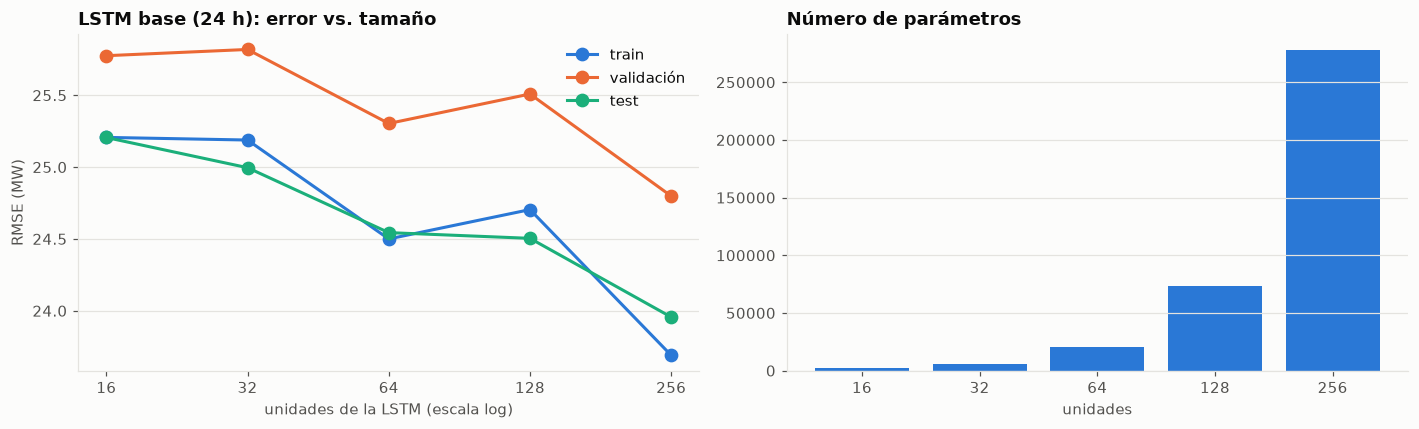

,epocas_entrenadas,mejor_epoca,parametros,RMSE_train,RMSE_val,RMSE_test_comun,R2_test_comun,brecha val−train
unidades LSTM,,,,,,,,
16,38,33,2001,25.21,25.78,25.21,0.90,0.57
32,27,22,6049,25.19,25.82,25.00,0.90,0.63
64,31,26,20289,24.50,25.30,24.54,0.90,0.80
128,25,20,73345,24.70,25.51,24.50,0.90,0.80
256,34,29,277761,23.69,24.80,23.96,0.91,1.11


In [2]:
ids = {16: "unidades_A_16", 32: "unidades_A_32", 64: "grid_A_n24_B", 128: "unidades_A_128", 256: "unidades_A_256"}
u = res.loc[list(ids.values()), COLS].copy(); u.index = list(ids.keys()); u.index.name = "unidades LSTM"
u["brecha val−train"] = u.RMSE_val - u.RMSE_train
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(u.index, u.RMSE_train, marker="o", color=AZUL, label="train")
ax[0].plot(u.index, u.RMSE_val, marker="o", color=NARANJA, label="validación")
ax[0].plot(u.index, u.RMSE_test_comun, marker="o", color=AQUA, label="test")
ax[0].set_xscale("log", base=2); ax[0].set_xticks(u.index, u.index)
ax[0].set_xlabel("unidades de la LSTM (escala log)"); ax[0].set_ylabel("RMSE (MW)"); ax[0].legend()
ax[0].set_title("LSTM base (24 h): error vs. tamaño")
ax[1].bar([str(i) for i in u.index], u.parametros, color=AZUL)
ax[1].set_title("Número de parámetros"); ax[1].set_xlabel("unidades")
plt.tight_layout(); plt.savefig(FIG / "06_unidades.png"); plt.show()
u.round(2)

**Lectura:**
- **De 16 a 64 neuronas** el error baja de forma clara (test 25.2 → 24.5 MW).
- **De 64 a 128 no mejora**: la validación incluso empeora (25.30 → 25.51 MW).
- **256 neuronas logra el mejor resultado** (test 23.96 MW, val 24.80). Pero cuesta **14 veces más parámetros** (277 761 vs. 20 289) y **10 veces más tiempo** (247 s vs. 25 s) a cambio de ~0.6 MW. Además, la brecha validación−entrenamiento crece con el tamaño (0.57 → 1.11 MW): el modelo grande empieza a memorizar más.
- La relación **no es monótona**, y las diferencias de ~0.5 MW están en el orden de la variación por semilla.

## 2. Dropout (pregunta 4)

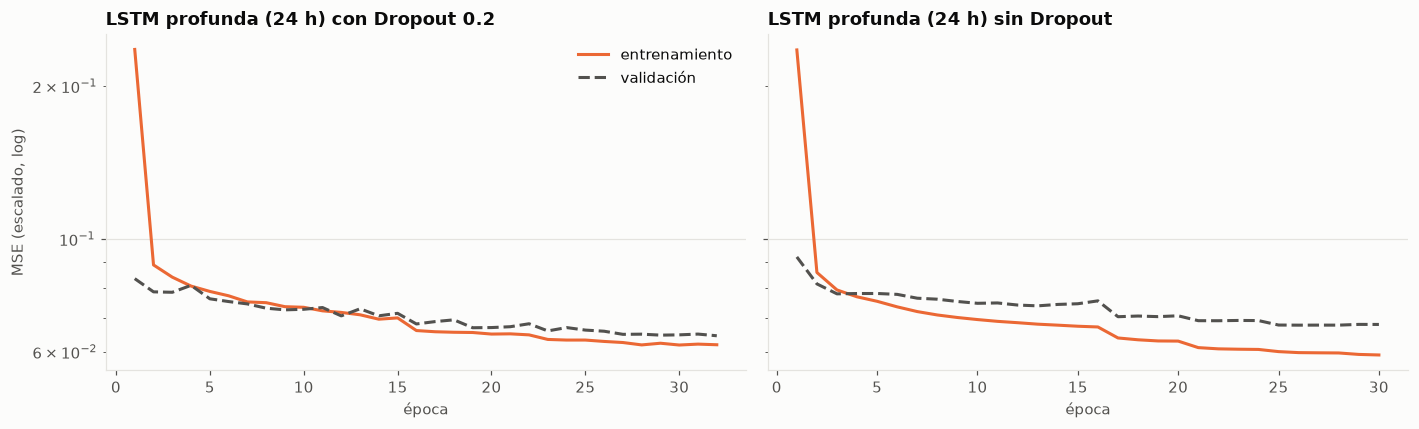

,epocas_entrenadas,mejor_epoca,parametros,RMSE_train,RMSE_val,RMSE_test_comun,R2_test_comun,brecha val−train
B con Dropout 0.2,32,27,135585,24.039,25.065,24.128,0.906,1.026
B sin Dropout,30,25,135585,23.963,25.599,24.398,0.904,1.636


In [3]:
d = res.loc[["grid_B_n24_B", "dropout_B_sin"], COLS].copy()
d.index = ["B con Dropout 0.2", "B sin Dropout"]
d["brecha val−train"] = d.RMSE_val - d.RMSE_train
fig, ax = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for a, (id_, nombre) in zip(ax, [("grid_B_n24_B", "con Dropout 0.2"), ("dropout_B_sin", "sin Dropout")]):
    h = hist(id_); ep = np.arange(1, len(h["loss"]) + 1)
    a.plot(ep, h["loss"], color=NARANJA, label="entrenamiento"); a.plot(ep, h["val_loss"], color=TINTA_2, linestyle="--", label="validación")
    a.set_title(f"LSTM profunda (24 h) {nombre}"); a.set_xlabel("época"); a.set_yscale("log")
ax[0].set_ylabel("MSE (escalado, log)"); ax[0].legend()
plt.tight_layout(); plt.savefig(FIG / "06_dropout.png"); plt.show()
d.round(3)

**Qué es:** durante el entrenamiento, el Dropout "apaga" al azar una fracción de las neuronas en cada paso (aquí el 20 %). Así la red no puede depender de unas pocas conexiones y se ve obligada a aprender representaciones redundantes y robustas. En la predicción todas las neuronas están activas.

**Efecto medido (LSTM profunda, 135 585 parámetros):**

| | RMSE train | RMSE val | Brecha val−train | RMSE test |
|---|---|---|---|---|
| Con Dropout 0.2 | 24.04 | **25.07** | **1.03** | **24.13** |
| Sin Dropout | 23.96 | 25.60 | 1.64 | 24.40 |

Sin Dropout el modelo se ajusta **un poco mejor a train** pero **peor a validación y test**. La brecha crece un 60 %: es el patrón clásico del inicio del sobreajuste. El Dropout es más útil justamente en el modelo más grande, que es el que tiene más capacidad de memorizar.

## 3. Early Stopping (pregunta 5)

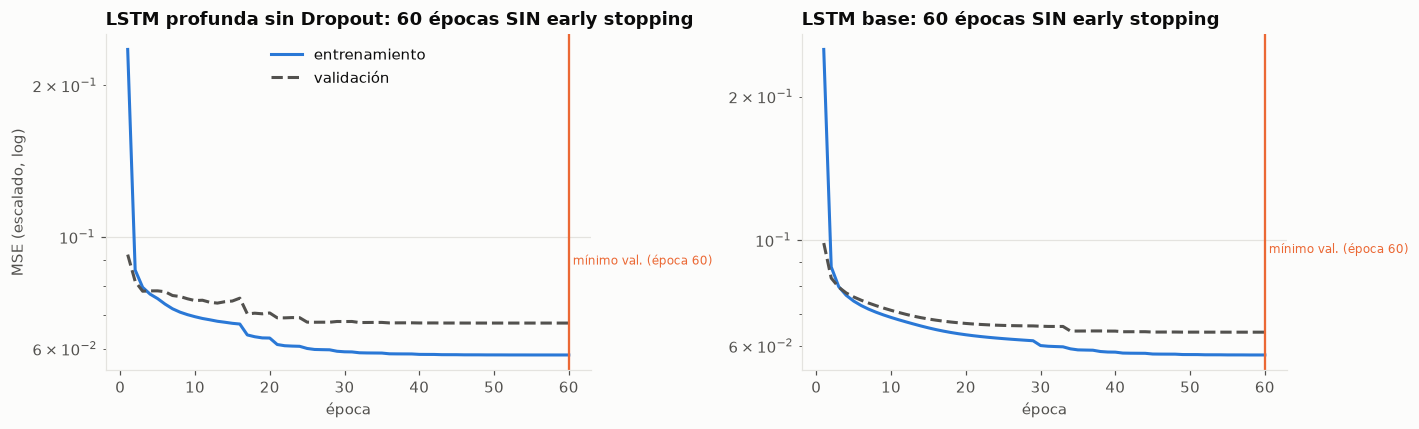

,modelo,época del mínimo de validación,val_loss mínima,val_loss en la última época,"RMSE test (sin ES, última época)"
0,LSTM profunda sin Dropout,60,0.0674,0.0674,24.3161
1,LSTM base,60,0.0641,0.0641,24.2825


In [4]:
casos = [("sin_es_B_sin_dropout", "grid_B_n24_B", "LSTM profunda sin Dropout"), ("sin_es_A", "grid_A_n24_B", "LSTM base")]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
filas = []
for a, (id_sin, id_con, nombre) in zip(ax, casos):
    h = hist(id_sin); ep = np.arange(1, len(h["loss"]) + 1)
    mejor = int(np.argmin(h["val_loss"])) + 1
    a.plot(ep, h["loss"], color=AZUL, label="entrenamiento"); a.plot(ep, h["val_loss"], color=TINTA_2, linestyle="--", label="validación")
    a.axvline(mejor, color=NARANJA, linewidth=1.5)
    a.text(mejor, max(h["val_loss"]), f" mínimo val. (época {mejor})", color=NARANJA, fontsize=8, va="top")
    a.set_yscale("log"); a.set_title(f"{nombre}: 60 épocas SIN early stopping"); a.set_xlabel("época")
    filas.append({"modelo": nombre, "época del mínimo de validación": mejor,
                  "val_loss mínima": min(h["val_loss"]), "val_loss en la última época": h["val_loss"][-1],
                  "RMSE test (sin ES, última época)": res.loc[id_sin, "RMSE_test_comun"]})
ax[0].set_ylabel("MSE (escalado, log)"); ax[0].legend()
plt.tight_layout(); plt.savefig(FIG / "06_early_stopping.png"); plt.show()
pd.DataFrame(filas).round(4)

**Qué es:** se vigila la pérdida de **validación** en cada época. Si no mejora (aquí: al menos ~0.1 MW en 5 épocas), el entrenamiento se detiene y se **restauran los pesos de la mejor época**. Evita seguir entrenando cuando el modelo ya no generaliza mejor, o cuando empieza a memorizar.

**Efecto medido:**
- **En 60 épocas sin Early Stopping la validación nunca empezó a subir**, pero **se aplanó desde la época ~25–35, mientras el entrenamiento siguió bajando**. La brecha entre ambas se abre: es el inicio de la memorización. La ganancia en validación de ahí en adelante fue mínima (LSTM base: 25.27 → 24.92 MW). En 60 épocas el sobreajuste es incipiente, no dañino.
- Por eso, en este problema el Early Stopping funcionó sobre todo como **ahorro de tiempo**: detuvo los modelos en las épocas 15–35 sacrificando ~0.3 MW.
- La primera versión del entrenamiento (paciencia 10, sin mejora mínima; ver `resultados/analisis_paciencia10.csv`) gastaba el **73 % del tiempo en ganar menos de 0.5 MW**.
- **Su papel como protección sigue siendo importante:** sin saber de antemano cuántas épocas hacen falta, garantiza que nunca se use un modelo sobreentrenado, porque siempre restaura el mejor punto de validación.

## 4. ¿Qué variables influyen más? (pregunta 8)

### 4.1 Ablación: re-entrenar quitando o agregando variables (LSTM base, 24 h)

In [5]:
ab = res.loc[["grid_A_n24_B", "ablacion_sin_clima", "ablacion_sin_precio", "ablacion_con_viento_lluvia"],
             ["n_features", "RMSE_val", "RMSE_test_comun", "R2_test_comun"]].copy()
ab.index = ["Modelo completo", "Sin clima (temp, hum, rad)", "Sin precio", "Con viento y lluvia"]
ab["Δ RMSE test vs completo"] = ab.RMSE_test_comun - ab.loc["Modelo completo", "RMSE_test_comun"]
ab.round(3)

,n_features,RMSE_val,RMSE_test_comun,R2_test_comun,Δ RMSE test vs completo
Modelo completo,14,25.303,24.544,0.903,0.000
"Sin clima (temp, hum, rad)",11,25.792,24.365,0.905,-0.179
Sin precio,13,25.006,24.242,0.906,-0.301
Con viento y lluvia,16,25.632,24.952,0.900,0.408


### 4.2 Importancia por permutación (mejor modelo)

Se baraja una variable entre las muestras del test, rompiendo su relación con la demanda, y se mide cuánto empeora el RMSE. Cuanto más empeora, más **depende el modelo** de esa variable.

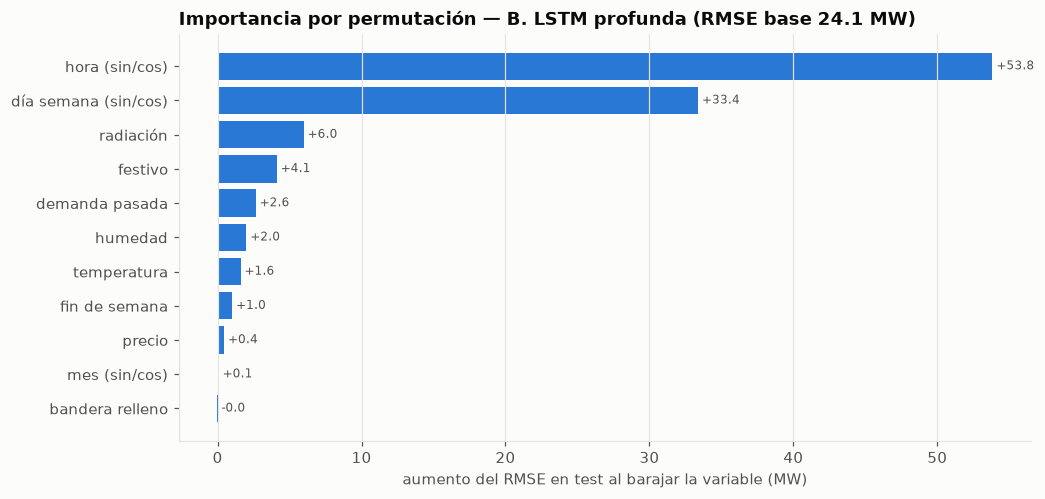

hora (sin/cos)          53.83
día semana (sin/cos)    33.37
radiación                5.98
festivo                  4.11
demanda pasada           2.64
humedad                  1.99
temperatura              1.59
fin de semana            1.01
precio                   0.45
mes (sin/cos)            0.07
bandera relleno         -0.01
dtype: float64

In [6]:
cfg = json.loads((RAIZ / "resultados/modelo_produccion.json").read_text(encoding="utf-8"))
df = pd.read_parquet(RAIZ / "data/processed/dataset_limpio.parquet")
datos = P.preparar(df, cfg["ventana"], cfg["tratamiento"])
modelo = keras.models.load_model(RAIZ / "resultados/modelos" / f"{cfg['id']}.keras")
esc, X, y = datos["escaladores"], datos["test"]["X"], datos["test"]["y_mw"]
feats = datos["features"]
grupos = {"demanda pasada": ["demanda"], "temperatura": ["temperatura_c"], "humedad": ["humedad_pct"],
          "radiación": ["radiacion_wm2"], "precio": ["precio_kwh"], "hora (sin/cos)": ["hora_sin", "hora_cos"],
          "día semana (sin/cos)": ["dia_sin", "dia_cos"], "mes (sin/cos)": ["mes_sin", "mes_cos"],
          "fin de semana": ["fin_semana"], "festivo": ["festivo"], "bandera relleno": ["flag_exogena_rellenada"]}
rmse_base = metricas(y, esc.invertir_y(modelo.predict(X, batch_size=1024, verbose=0)))["RMSE"]
rng = np.random.default_rng(0)
imp = {}
for g, cols in grupos.items():
    idx = [feats.index(c) for c in cols]
    subidas = []
    for _ in range(3):
        Xp = X.copy(); perm = rng.permutation(len(X))
        Xp[:, :, idx] = X[perm][:, :, idx]   # se baraja la variable completa entre muestras
        subidas.append(metricas(y, esc.invertir_y(modelo.predict(Xp, batch_size=1024, verbose=0)))["RMSE"] - rmse_base)
    imp[g] = np.mean(subidas)
imp = pd.Series(imp).sort_values()
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.barh(imp.index, imp.values, color=AZUL)
for i, v in enumerate(imp.values):
    ax.text(v, i, f" {v:+.1f}", va="center", fontsize=8, color=TINTA_2)
ax.set_xlabel("aumento del RMSE en test al barajar la variable (MW)")
ax.set_title(f"Importancia por permutación — {cfg['nombre']} (RMSE base {rmse_base:.1f} MW)")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
plt.savefig(FIG / "06_importancia_permutacion.png"); plt.show()
imp.sort_values(ascending=False).round(2)

**Lectura conjunta:**
- **El calendario domina:** la hora del día (+54 MW si se baraja) y el día de la semana (+33 MW) son, por mucho, lo que más usa el modelo. Coincide con el EDA: la hora tiene la mayor información mutua y el patrón semanal tiene ACF 0.92.
- **Radiación (+6), festivo (+4) y demanda pasada (+2.6)** aportan ajustes finos. Que la demanda pasada pese tan poco es contraintuitivo, dado que su ACF de lag 1 es 0.88. La explicación es que **casi toda esa autocorrelación viene del ciclo diario y semanal, que el calendario ya codifica**. La demanda pasada solo agrega la parte no explicada por el calendario (ver sección 5).
- **Ablación:** quitar el clima o el precio **no empeora** el test (−0.2 y −0.3 MW), y en validación los cambios son mixtos. Agregar viento y lluvia **empeora** (+0.4 MW): son ruido, como anticipó el EDA.
- **¿Por qué la radiación importa en la permutación pero quitar el clima no empeora?** Porque las variables están **correlacionadas**. Si se re-entrena sin clima, el modelo recupera esa información del calendario (mes, hora) y de la demanda reciente, que ya refleja el clima. La permutación mide de qué depende *este* modelo; la ablación mide qué es *imprescindible*.
- El **precio** casi no aporta (+0.45). Coherente con el EDA: su relación global con la demanda venía de compartir el ciclo diario.

## 5. ¿Queda algo por aprender? Autocorrelación de los residuos

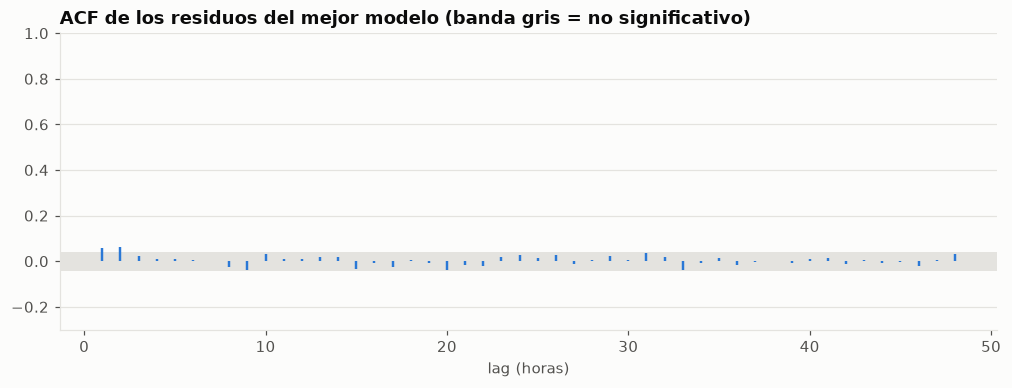

ACF residuos: lag1=0.060  lag24=0.026  | banda ±0.042
Comparar con la ACF de la demanda original: lag1=0.879, lag24=0.749


In [7]:
from statsmodels.tsa.stattools import acf
p = pd.read_parquet(E.DIR_RES / f"{cfg['id']}_pred_test.parquet").set_index("ts_objetivo")
p = p.reindex(pd.date_range(p.index.min(), p.index.max(), freq="h"))
residuo = p.real - p.pred
a = acf(residuo, nlags=48, missing="drop")
banda = 1.96 / np.sqrt(residuo.notna().sum())
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.vlines(range(1, 49), 0, a[1:], color=AZUL, linewidth=1.6)
ax.axhspan(-banda, banda, color=REJILLA, linewidth=0)
ax.set_ylim(-0.3, 1); ax.set_xlabel("lag (horas)")
ax.set_title("ACF de los residuos del mejor modelo (banda gris = no significativo)")
plt.savefig(FIG / "06_acf_residuos.png"); plt.show()
print(f"ACF residuos: lag1={a[1]:.3f}  lag24={a[24]:.3f}  | banda ±{banda:.3f}")
print("Comparar con la ACF de la demanda original: lag1=0.879, lag24=0.749")

**Hallazgo clave:**
- La demanda original tiene ACF de 0.88 (lag 1) y 0.75 (lag 24). Los **residuos del modelo tienen ~0.06**, prácticamente en la banda de "no significativo". El modelo extrajo casi toda la estructura temporal predecible, y **lo que queda es ruido impredecible**.
- Esto explica por qué **las 3 arquitecturas, las 3 ventanas y los distintos tamaños se estancan en ~24–25 MW**: es el **techo de predictibilidad** de este dataset. Más capas, más neuronas o ventanas más largas no pueden aprender algo que no está en los datos.
- Por la misma razón, las diferencias entre modelos son pequeñas.

---
# Respuestas a las preguntas del taller

### 1. ¿Por qué LSTM es apropiada para este problema?
- La demanda es una **serie temporal con dependencias en varias escalas**: horaria (ACF lag 1 = 0.88), diaria (lag 24 = 0.75) y semanal (lag 168 = 0.92). Para predecir la próxima hora hay que "recordar" lo ocurrido horas atrás.
- Una **red recurrente simple** sufre el **desvanecimiento del gradiente**: al propagar el error hacia atrás por muchos pasos, se multiplica una y otra vez por números pequeños y se anula. En la práctica, no aprende dependencias de más de unos pocos pasos.
- La **LSTM** resuelve esto con una **celda de memoria** y tres **compuertas** aprendidas:
  - la de **olvido** decide qué descartar de la memoria;
  - la de **entrada**, qué información nueva guardar;
  - la de **salida**, qué parte de la memoria usar para predecir.

  La celda se actualiza de forma aditiva, así que el gradiente puede fluir por muchos pasos sin desvanecerse.
- Además, la LSTM es **multivariada**: combina en cada hora la demanda, el clima y el calendario, y aprende **relaciones no lineales e interacciones**. Por ejemplo, el EDA mostró que la radiación cambia de signo según la hora y que la temperatura tiene una relación en "J".
- **Evidencia:** todas las LSTM (RMSE 24–26 MW) superan con amplitud a los métodos simples (persistencia 44 MW; estacional semanal 37 MW), con ~35 % menos error que el mejor baseline.

### 2. ¿Qué efecto tiene cambiar la ventana temporal?
- **12 → 24 h mejora** en las tres arquitecturas: con 24 h el modelo ve la misma hora del día anterior (ACF lag 24 = 0.75).
- **24 → 48 h no mejora** en la LSTM base ni en la profunda, y cuesta ~2 veces más tiempo por época. La PACF mostró que después del lag ~27 no hay información nueva.
- La **Conv1D + LSTM es la excepción parcial**: con el tratamiento B su mejor ventana es 48 h (24.83 MW), coherente con que sus convoluciones aprovechan secuencias largas; con el tratamiento A no se repite (24 h es mejor).
- **Ventanas más largas** = más contexto, pero también más parámetros efectivos, más tiempo, más riesgo de sobreajuste y menos muestras válidas (con el tratamiento A, 48 h tiene un 9 % menos de muestras de train que 12 h).
- **Recomendación: 24 h.** Ninguna ventana del taller alcanza el patrón semanal (168 h); por eso las variables de calendario son imprescindibles.

### 3. ¿Existe sobreajuste?
**No de forma relevante.**
- La brecha validación − entrenamiento es de solo **0.7–1.4 MW (3–6 %)** en todas las configuraciones.
- El error en **test** (oct–dic, nunca visto) es **igual o menor** que en validación.
- En 60 épocas sin Early Stopping la validación **nunca empezó a subir**.

**Por qué no hay sobreajuste:**
- muchos datos (~13 000 ventanas) frente al tamaño de los modelos;
- regularización (Dropout en B y C);
- Early Stopping;
- y que el error está dominado por ruido impredecible (sección 5), que el modelo no puede "memorizar" para generalizar.

**Señales incipientes:** el modelo de 256 neuronas y la LSTM profunda sin Dropout muestran brechas mayores (1.1 y 1.6 MW). Es la dirección en la que aparecería el sobreajuste si se aumentara la capacidad.

### 4. ¿Qué es y qué efecto tiene Dropout?
- **Qué es:** técnica de regularización que, en cada paso de entrenamiento, desactiva al azar una fracción de las neuronas (aquí el 20 %). Obliga a la red a no depender de conexiones específicas, como si se entrenara un "conjunto" de subredes. En la predicción se usan todas las neuronas.
- **Efecto medido** en la LSTM profunda:
  - **sin Dropout**, el error de entrenamiento baja (24.04 → 23.96 MW), pero el de validación sube (25.07 → 25.60) y la brecha crece un 60 % (1.03 → 1.64 MW);
  - el test también empeora (24.13 → 24.40).
- **Conclusión:** el Dropout reduce el sobreajuste y mejora la generalización, sobre todo en el modelo con más parámetros.

### 5. ¿Qué es y qué efecto tiene Early Stopping?
- **Qué es:** detener el entrenamiento cuando la pérdida de validación deja de mejorar durante un número de épocas (paciencia) y **restaurar los pesos de la mejor época**.
- **Efecto medido:**
  - con la configuración final (paciencia 5, mejora mínima ~0.1 MW), los modelos se detuvieron entre las épocas 14 y 40;
  - entrenar 60 épocas completas mejoró la validación solo ~0.3 MW, sin señales de sobreajuste;
  - con una configuración más permisiva (paciencia 10), el 73 % del tiempo se gastaba en ganar menos de 0.5 MW.
- **Conclusión:** en este problema su principal beneficio fue **eficiencia**: entrenamientos entre 2.5 y 4 veces más rápidos, con una pérdida de precisión mínima. Sigue siendo una **protección** indispensable, porque garantiza usar siempre el punto de mejor generalización sin tener que adivinar el número de épocas.

### 6. ¿Más neuronas implican necesariamente mejores resultados?
**No.**
- De 16 a 64 neuronas mejora.
- De 64 a 128 **no** mejora (la validación empeora).
- 256 logra el mejor resultado, pero con **14 veces más parámetros y 10 veces más tiempo** para ganar ~0.6 MW (2.4 %), y con una brecha val−train mayor.
- La LSTM profunda (135 585 parámetros) apenas supera a la base (20 289).
- **La razón de fondo** es el techo de predictibilidad: los residuos ya son casi ruido blanco (ACF lag 1 ≈ 0.06), así que más capacidad no tiene qué aprender y solo aumenta el costo y el riesgo de sobreajuste.
- La capacidad debe ajustarse a la complejidad real del problema.

### 7. ¿Qué modelo recomendaría para producción y por qué?
Hay dos candidatos razonables, y la decisión depende de la prioridad.

| | LSTM profunda (B), 24 h | LSTM base (A), 24 h |
|---|---|---|
| RMSE validación / test | **25.07 / 24.13 MW** | 25.30 / 24.54 MW |
| Parámetros | 135 585 | **20 289** (6.7× menos) |
| Tiempo de entrenamiento | ~200 s | **~25 s** |

- **Para la app de este taller se desplegó la LSTM profunda, 24 h, tratamiento B**, porque fue la de menor error de **validación**. El test no se usó para elegir; solo confirma la elección: también fue la mejor en test.
- **En un entorno de producción real** recomendaría la **LSTM base de 24 h** si se re-entrena con frecuencia o corre en hardware limitado. Su diferencia con la profunda (~0.4 MW, 1.7 %) está en el orden de la variación por semilla, y es 8 veces más rápida de entrenar y más simple de mantener.
- En ambos casos: **ventana de 24 h** (mejor equilibrio entre contexto y costo) y **tratamiento B** (puede predecir aunque una hora tenga un problema de medición).

### 8. ¿Qué variables pueden influir más en la demanda?
1. **Hora del día:** es la más importante para el modelo (+54 MW de error si se baraja). Define el ciclo diario de dos picos.
2. **Día de la semana / fin de semana** (+33 MW): los fines de semana la demanda baja ~16 %.
3. **Festivo** (+4 MW): baja la demanda como un fin de semana. Con solo 8 días en entrenamiento es el efecto peor aprendido (genera el mayor error del test, el 8-dic).
4. **Variables climáticas:** temperatura (relación en "J", la más robusta en el EDA), radiación (+6 MW en la permutación) y humedad. Su información está en parte contenida en el calendario y en la demanda reciente, por eso quitarlas no empeora el modelo re-entrenado.
5. **Demanda reciente:** aporta el ajuste de nivel que el calendario no explica.

**Poco o nada:** precio (+0.45 MW; su relación con la demanda era un efecto del ciclo diario), viento y precipitación (agregarlos empeora el modelo).

### 9. ¿Qué limitaciones tiene el modelo?
1. **Techo de predictibilidad:** el error restante (~24 MW, 3.3 %) es casi ruido impredecible. Ninguna arquitectura lo baja sustancialmente con estas variables.
2. **Subestima los picos** (sesgo de −13 a −19 MW en el 5 % de horas más altas), que son el error más costoso en operación.
3. **Festivos al inicio del día:** el modelo sí aprendió su efecto: con la ventana del 8-dic a las 08:00, si se quita la marca de festivo la predicción sube 106 MW. Pero lo aprende a partir de las **horas marcadas dentro de la ventana**. En la madrugada del festivo la ventana solo contiene 1–2 horas marcadas, y por eso se produce el mayor error del test (+119 MW el 8-dic a las 02:00). Hay dos causas: solo 8 días festivos en entrenamiento y que la entrada no incluye el calendario de la hora objetivo. **Mejora posible:** dar como entrada el calendario de la hora t+1 (festivo, hora, día). No es información futura indebida, porque el calendario se conoce de antemano.
4. **Horizonte de 1 hora:** solo predice la hora siguiente. Para planificar con más anticipación habría que predecir varias horas, y el error crece con el horizonte.
5. **Clima observado, no pronosticado:** usa el clima medido hasta la hora *t*. En producción, un modelo con más horizonte necesitaría pronósticos meteorológicos, que tienen su propio error.
6. **Poca historia:** 2 años de datos, con un solo verano en entrenamiento completo. El test (oct–dic) no evalúa la temporada de picos de verano.
7. **No ve el patrón semanal directamente:** la ventana máxima del taller (48 h) no alcanza el lag de 168 h, el más fuerte. Incluir la demanda de la semana anterior como entrada probablemente mejoraría los picos.
8. **Una sola semilla por configuración:** diferencias menores a ~0.5 MW entre modelos podrían deberse a la inicialización aleatoria.
9. **Origen de los datos no especificado:** el dataset no indica de qué sistema o región provienen los datos. Las conclusiones valen para este dataset; aplicarlas a un sistema real requeriría validarlas con sus datos.